# Experimento B: Acceso secuencial vs acceso aleatorio

**Objetivo:** Generar archivos de prueba en
CSV y Parquet, medir lecturas secuenciales y aleatorias, y comparar eficiencia por formato.

###  1. Importación de librerías

In [28]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq

### 2. Configuración general

In [29]:
# Definimos rutas según la estructura del repositorio
datos_dir = Path("../datos")
vis_dir = Path("../visualizaciones")
# Creamos las carpetas si no existen
datos_dir.mkdir(exist_ok=True)
vis_dir.mkdir(exist_ok=True)
# Parámetros del experimento
n_rows = 500_000
block_size = 5_000
repetitions = 3
n_random_blocks = 10
# Semilla para reproducibilidad
np.random.seed(42)

### 3. Generación del dataset de prueba

In [30]:
# Generamos un dataset sintético para comparar ambos formatos
df = pd.DataFrame({
    "id": np.arange(n_rows),
    "feature_1": np.random.rand(n_rows),
    "feature_2": np.random.randint(0, 1000, n_rows),
    "feature_3": np.random.choice(["A", "B", "C", "D"], n_rows),
    "feature_4": np.random.randn(n_rows)
})
df.head()

,id,feature_1,feature_2,feature_3,feature_4
0,0,0.374540,816,B,-0.504703
1,1,0.950714,566,D,-0.259500
2,2,0.731994,341,D,1.549238
3,3,0.598658,396,C,-0.084338
4,4,0.156019,278,C,1.231465


### 4. Guardado en CSV y Parquet

In [31]:
# Definimos archivos temporales
csv_path = Path("dataset_experimento_b.csv")
parquet_path = Path("dataset_experimento_b.parquet")
# Guardamos CSV
df.to_csv(csv_path, index=False)
# Guardamos Parquet con row groups del mismo tamaño que los bloques
table = pa.Table.from_pandas(df)
pq.write_table(table, parquet_path, row_group_size=block_size)
print("Archivos de prueba creados correctamente.")

Archivos de prueba creados correctamente.


### 5. Funciones auxiliares de medición

In [32]:
# Lectura secuencial: leer el archivo completo
def medir_lectura_secuencial_csv(path):
    start = time.perf_counter()
    _ = pd.read_csv(path)
    end = time.perf_counter()
    return end - start
def medir_lectura_secuencial_parquet(path):
    start = time.perf_counter()
    _ = pd.read_parquet(path)
    end = time.perf_counter()
    return end - start
# Lectura aleatoria en CSV por bloques
# Cada bloque se obtiene saltando filas hasta llegar al inicio del bloque
def medir_lectura_aleatoria_csv(path, block_indices, block_size):
    times = []
    for block_idx in block_indices:
        start_row = block_idx * block_size
        start = time.perf_counter()
        _ = pd.read_csv(
            path,
            skiprows=range(1, start_row + 1),
            nrows=block_size
        )
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times)
# Lectura aleatoria en Parquet por row groups
# Cada row group corresponde a un bloque de filas
def medir_lectura_aleatoria_parquet(path, block_indices):
    parquet_file = pq.ParquetFile(path)
    times = []
    for block_idx in block_indices:
        start = time.perf_counter()
        _ = parquet_file.read_row_group(block_idx).to_pandas()
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times)

### 6. Selección de filas aleatorias

In [33]:
# Calculamos cantidad total de bloques disponibles
n_blocks = n_rows // block_size
# Elegimos bloques aleatorios
random_blocks = np.random.choice(n_blocks, size=n_random_blocks, replace=False)
print("Bloques aleatorios seleccionados:", random_blocks)

Bloques aleatorios seleccionados: [17 19 62  2 30 93 77  3 10  8]


### 7.Ejecución de mediciones

In [34]:
# Listas para guardar tiempos
csv_seq_times = []
parquet_seq_times = []
csv_rand_times = []
parquet_rand_times = []
for _ in range(repetitions):
    csv_seq_times.append(medir_lectura_secuencial_csv(csv_path))
    parquet_seq_times.append(medir_lectura_secuencial_parquet(parquet_path))
    csv_rand_times.append(medir_lectura_aleatoria_csv(csv_path, random_blocks, block_size))
    parquet_rand_times.append(medir_lectura_aleatoria_parquet(parquet_path, random_blocks))
# Consolidamos resultados
resultados_b = pd.DataFrame({
    "formato": ["CSV", "Parquet"],
    "lectura_secuencial_s": [
        np.mean(csv_seq_times),
        np.mean(parquet_seq_times)
    ],
    "lectura_aleatoria_s": [
        np.mean(csv_rand_times),
        np.mean(parquet_rand_times)
    ]
})
resultados_b

,formato,lectura_secuencial_s,lectura_aleatoria_s
0,CSV,0.149312,0.023942
1,Parquet,0.012605,0.000436


### 8. Cálculo de throughput secuencial

In [35]:
# Calculamos tamaño real de los archivos en MB
csv_size_mb = csv_path.stat().st_size / (1024 ** 2)
parquet_size_mb = parquet_path.stat().st_size / (1024 ** 2)
# Calculamos throughput secuencial
resultados_b["throughput_secuencial_mb_s"] = [
    csv_size_mb / resultados_b.loc[resultados_b["formato"] == "CSV", "lectura_secuencial_s"].values[0],
    parquet_size_mb / resultados_b.loc[resultados_b["formato"] == "Parquet", "lectura_secuencial_s"].values[0]
]
resultados_b

,formato,lectura_secuencial_s,lectura_aleatoria_s,throughput_secuencial_mb_s
0,CSV,0.149312,0.023942,167.885201
1,Parquet,0.012605,0.000436,1036.287344


### 9. Guardado de resultados

In [36]:
# Guardamos resultados en la carpeta datos
resultados_b.to_csv(datos_dir / "resultados_experimento_b.csv", index=False)
print("Resultados guardados correctamente.")

Resultados guardados correctamente.


### 10. Visualización: lectura secuencial

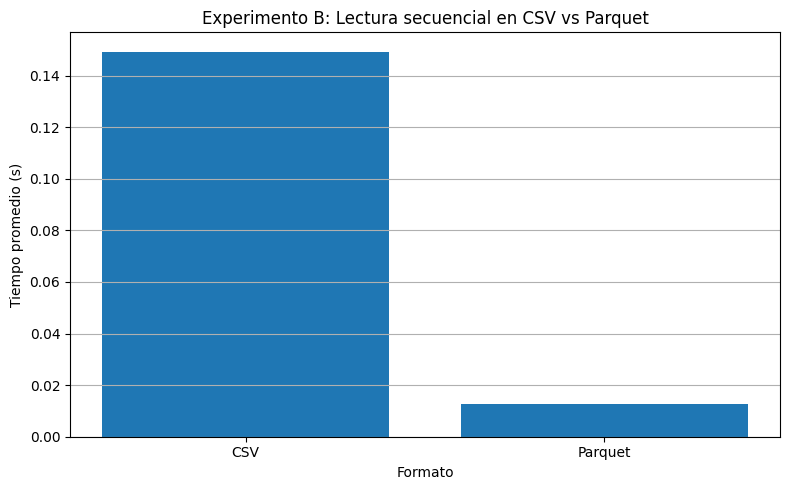

In [37]:
# Graficamos tiempos de lectura secuencial
plt.figure(figsize=(8, 5))
plt.bar(resultados_b["formato"], resultados_b["lectura_secuencial_s"])
plt.xlabel("Formato")
plt.ylabel("Tiempo promedio (s)")
plt.title("Experimento B: Lectura secuencial en CSV vs Parquet")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(vis_dir / "grafico_experimento_b_lectura_secuencial.png")
plt.show()

### 11. Visualización: lectura aleatoria

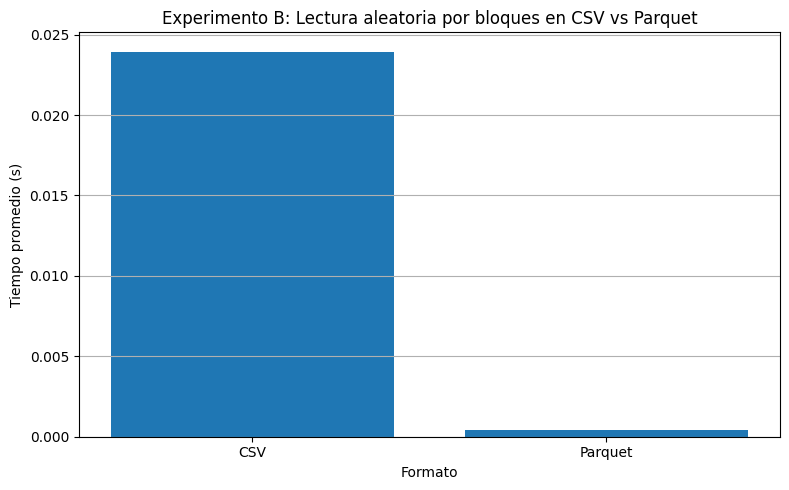

In [38]:
# Graficamos tiempos de lectura aleatoria
plt.figure(figsize=(8, 5))
plt.bar(resultados_b["formato"], resultados_b["lectura_aleatoria_s"])
plt.xlabel("Formato")
plt.ylabel("Tiempo promedio (s)")
plt.title("Experimento B: Lectura aleatoria por bloques en CSV vs Parquet")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(vis_dir / "grafico_experimento_b_lectura_aleatoria.png")
plt.show()

### 12. Visualización: throughput secuencial

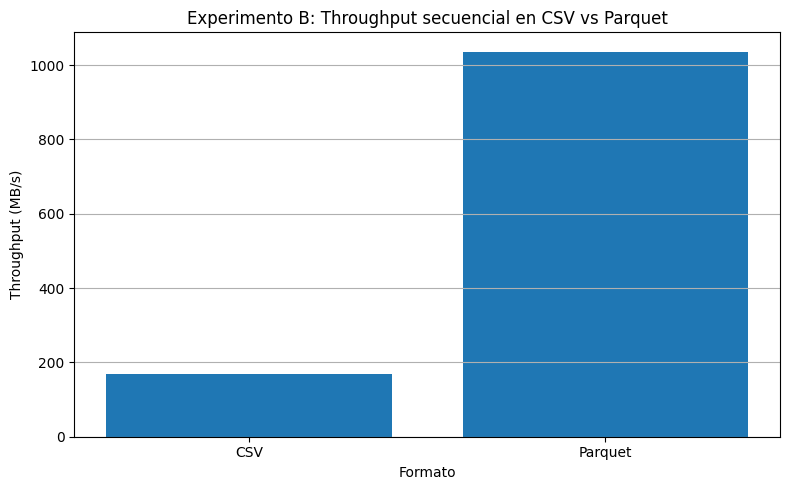

In [39]:
# Graficamos throughput de lectura secuencial
plt.figure(figsize=(8, 5))
plt.bar(resultados_b["formato"], resultados_b["throughput_secuencial_mb_s"])
plt.xlabel("Formato")
plt.ylabel("Throughput (MB/s)")
plt.title("Experimento B: Throughput secuencial en CSV vs Parquet")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(vis_dir / "grafico_experimento_b_throughput.png")
plt.show()

### 13. Limpieza de archivos temporales

In [40]:
# Eliminamos archivos temporales
if csv_path.exists():
    csv_path.unlink()
if parquet_path.exists():
    parquet_path.unlink()
print("Archivos temporales eliminados.")

Archivos temporales eliminados.
